# ```TriPoD```-```Athena++``` data tutorial

## Short Introduction to ```TriPoD```
```TriPoD``` is a semi-analytic model for dust evolution in protoplanetary disks. Two dust populations and a maximum particle size are used to model coagulation and fragmentation.
Although ```TriPoD``` only evolved two dustfluids, it can be used to reconstruct a full size distribution.
The underlying assumption is that the dust size distribution is a truncated power law $n(a)\propto a^q \Theta(a_\mathrm{max}-a)$, i.e.,
$$
\Sigma_\mathrm{d}(a)=
    Ca^{q+3} \quad \text{for}\, a_\mathrm{min}\leq a\leq a_\mathrm{max}
$$
where $C$ is a normalization constant, such that $\Sigma_\mathrm{d,tot} = \int \Sigma_\mathrm{d}(a)\, \mathrm{d}a$.
To get to the ```TriPoD``` model, we integrate this distribution over two bins from $a_\mathrm{min}$ to $\sqrt{a_\mathrm{min}a_\mathrm{max}}$ and from $\sqrt{a_\mathrm{min}a_\mathrm{max}}$ to $a_\mathrm{max}$:
\begin{align}
\Sigma_0 &= \int_{a_\mathrm{min}}^{\sqrt{a_\mathrm{min}a_\mathrm{max}}} \Sigma_\mathrm{d}(a) \, \mathrm{d}a = \Sigma_{\text{d,tot}}\frac{a_\mathrm{max}^{q+4}-(a_\mathrm{max}a_\mathrm{min})^{\frac{q+4}{2}}}{a_\mathrm{max}^{q+4}-a_\mathrm{min}^{q+4}} & \text{for } q\neq -4 \\
\Sigma_1 &= \int_{\sqrt{a_\mathrm{min}a_\mathrm{max}}}^{a_\mathrm{max}} \, \, \, \Sigma_\mathrm{d}(a) \, \mathrm{d}a = \Sigma_{\text{d,tot}}\frac{(a_\mathrm{max}a_\mathrm{min})^{\frac{q+4}{2}}-a_\mathrm{min}^{q+4}}{a_\mathrm{max}^{q+4}-a_\mathrm{min}^{q+4}}
\end{align}

And from these definitions, we can exactly describe the exponent of the distribution via
$$
q = 2 \frac{\log\left(\frac{\Sigma_1}{\Sigma_0}\right)}{\log\left(\frac{a_\mathrm{max}}{a_\mathrm{min}}\right)} - 4
$$
Knowing the ***three variables $\Sigma_\mathrm{d}$, $a_\mathrm{max}$ and $q$*** we can reconstruct a full size distribution or calculate mass-averaged particle sizes of our size distribution.
The ```TriPoD``` model itself is a set of ***two ordinary differential equations*** for $\Sigma_0$ (and thus $\Sigma_1$, assuming mass conservation during coagulation), and $a_\mathrm{max}$. These equations are designed to relax the size distribution towards a predetermine size distribution exponent $q_\mathrm{exp}$, which is informed by numerical solutions to the Smoluchowski equation (calculated with ```DustPy```). 
For example: if turbulent collision velocities dominate particle-particle interactions, the distribution will evolve towards and MRN size distribution, with $q_\mathrm{exp}=-3.5$, on the dust collisional timescale. 

This relaxation occurs on the relevant collisional timescale of the dust particles. Please ask me or have a look at the paper if you want to know how these relaxation rates are determines in the code.

## 1. Loading the simulation data 
First, we import a helper function to read ```Athena++``` data (this is taken from https://github.com/PrincetonUniversity/athena). 
We also need ```h5py``` to load the files. You can use ```pip install h5py``` if you don't have it installed.

We will load and plot some data of a planet-disk simulation with the ```Athena++``` multifluid module and TriPoD.
The data files provided here are the nominal simulation from Pfeil, Armitage, and Jiang (2025).
In that paper, we studied how dust coagulation and fragmentation determine how much dust can diffuse through planet-induced gaps.

The setup is an initially smooth disk, perturbed by the gravitational potential of a planet on a fixed Keplerian orbit.

In [6]:
# For data loading and evaluation:
import sys
import athena_read
import numpy as np

# For plotting:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.gridspec as gridspec

This dictionary, ```data```, contains the entire simulation snapshot.
Note that, since ```Athena++``` outputs are single precision data, ```athena_read``` also returns single precision numpy arrays as dictionary entries. 

We start setting up the grid to make some basic plots showing the disk structure.

In [7]:
Nfile = 0
data  = athena_read.athdf("nominal_sim/disk.out1." + f"{Nfile:05}" + ".athdf")  

In [8]:
#
# Settling up the spatial grid (cylindrical polar coordinates 
# with only 1 vertical grid cell)
#
ri   = data['x1f'] # radial grid cell interfaces
phii = data['x2f'] # azimuthal grid cell interfaces
r    = data['x1v'] # radial grid cell centers
phi  = data['x2v'] # azimuthal grid cell centers

R, Phi = np.meshgrid(r, phi)

# Make a cartesian grid for plotting
x   = ri[None,:]*np.sin(phii[:,None]) 
y   = ri[None,:]*np.cos(phii[:,None])  

#
# Retrieve some of the important simulation outputs
#
sigg   = data['rho'][0]
sigd_0 = data['dust_1_rho'][0]
sigd_1 = data['dust_2_rho'][0]
amax   = data['r0'][0]

Let's calculate the size distribution index following the above equations.

In [9]:
amin = 1e-5 
# This a constant input parameter for 
# the model that needs to be specified fpor each simulation

q = 2.*np.log(sigd_1/sigd_0)/np.log(amax/amin) - 4.
print ("amax =",  amax,"\n", "q =", q)

amax = [[1.e-04 1.e-04 1.e-04 ... 1.e-04 1.e-04 1.e-04]
 [1.e-04 1.e-04 1.e-04 ... 1.e-04 1.e-04 1.e-04]
 [1.e-04 1.e-04 1.e-04 ... 1.e-04 1.e-04 1.e-04]
 ...
 [1.e-04 1.e-04 1.e-04 ... 1.e-04 1.e-04 1.e-04]
 [1.e-04 1.e-04 1.e-04 ... 1.e-04 1.e-04 1.e-04]
 [1.e-04 1.e-04 1.e-04 ... 1.e-04 1.e-04 1.e-04]] 
 q = [[-3.5 -3.5 -3.5 ... -3.5 -3.5 -3.5]
 [-3.5 -3.5 -3.5 ... -3.5 -3.5 -3.5]
 [-3.5 -3.5 -3.5 ... -3.5 -3.5 -3.5]
 ...
 [-3.5 -3.5 -3.5 ... -3.5 -3.5 -3.5]
 [-3.5 -3.5 -3.5 ... -3.5 -3.5 -3.5]
 [-3.5 -3.5 -3.5 ... -3.5 -3.5 -3.5]]


As we can see, I initized this simulation with an MRN dust size distribition between $a_\mathrm{min}=10^{-5}$ and $a_\mathrm{max}=10^{-4}$.
Let's plot the initial disk structure:

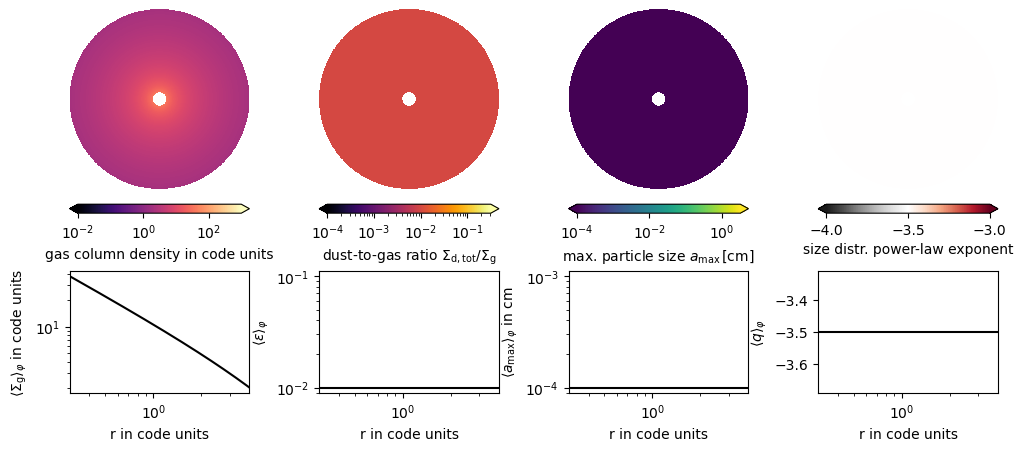

In [10]:
fig  = plt.figure(1, figsize=(10,5))
gs   = gridspec.GridSpec(2,4, height_ratios=[1,0.4])

ax0  = plt.subplot(gs[0,0])
ax0i = plt.subplot(gs[1,0])

ax1  = plt.subplot(gs[0,1])
ax1i = plt.subplot(gs[1,1])

ax2  = plt.subplot(gs[0,2])
ax2i = plt.subplot(gs[1,2])

ax3  = plt.subplot(gs[0,3])
ax3i = plt.subplot(gs[1,3])

plot0 = ax0.pcolormesh(x,y,sigg,norm=LogNorm(vmin=1e-2,vmax=1e3), cmap='magma', rasterized=True)
ax0.axis('off')
ax0.set_xlim(-20,20)
ax0.axis('scaled')
plt.colorbar(plot0, ax=ax0, orientation='horizontal', label=r'gas column density in code units', extend='both', pad=0.05)
ax0i.loglog(r, sigg.mean(0), color='k')
ax0i.set_xlabel("r in code units")
ax0i.set_ylabel(r"$\langle \Sigma_\mathrm{g} \rangle_\varphi$ in code units")
ax0i.set_xlim(r.min(), r.max())

plot1 = ax1.pcolormesh(x,y,(sigd_0 + sigd_1)/sigg, norm=LogNorm(vmin=1e-4, vmax=np.sqrt(0.1*1)), cmap='inferno', rasterized=True)
ax1.set_xlim(-20,20)
ax1.axis('scaled')
ax1.axis('off')
plt.colorbar(plot1, ax=ax1, orientation='horizontal', label=r'dust-to-gas ratio $\Sigma_\mathrm{d,tot}/\Sigma_\mathrm{g}$', extend='both', pad=0.05)
ax1i.loglog(r, ((sigd_0 + sigd_1)/sigg).mean(0), color='k')
ax1i.set_xlabel("r in code units")
ax1i.set_ylabel(r"$\langle \varepsilon \rangle_\varphi$")
ax1i.set_xlim(r.min(), r.max())

plot2 = ax2.pcolormesh(x,y,amax, norm=LogNorm(vmin=1e-4, vmax=np.sqrt(1*10)), cmap='viridis', rasterized=True)
ax2.set_xlim(-20,20)
ax2.axis('scaled')
ax2.axis('off')
plt.colorbar(plot2, ax=ax2, orientation='horizontal', label=r'max. particle size $a_\mathrm{\max} \, \mathrm{[cm]}$',extend='both', pad=0.05)
ax2i.loglog(r, amax.mean(0), color='k')
ax2i.set_xlabel("r in code units")
ax2i.set_ylabel(r"$\langle a_\mathrm{max} \rangle_\varphi$ in cm")
ax2i.set_xlim(r.min(), r.max())

plot3 = ax3.pcolormesh(x,y,q, vmin=-4., vmax=-3.0, cmap='RdGy_r', rasterized=True)
ax3.set_xlim(-20,20)
ax3.axis('scaled')
ax3.axis('off')
plt.colorbar(plot3, ax=ax3, orientation='horizontal', label=r'size distr. power-law exponent', extend='both', pad=0.05)
ax3i.semilogx(r, q.mean(0), color='k')
ax3i.set_xlabel("r in code units")
ax3i.set_ylabel(r"$\langle q \rangle_\varphi$")
ax3i.set_xlim(r.min(), r.max())

gs.tight_layout(fig, pad=0.1, h_pad=-0.5)

That's pretty boring as its just the initial condition (a smooth protoplanetary disk with micron sized particles). 
So let's load the last snapshot of the simulation instead. Outputs were generated every 100 planetary orbits, so the snapshot we load is taken after 45,000 planetary orbits.

In [13]:
def load_file(directory, Nfile):
    data  = athena_read.athdf(directory + "/disk.out1." + f"{Nfile:05}" + ".athdf") 
    
    time   = data["Time"].astype(np.double) 
    sigg   = data['rho'][0].astype(np.double)
    sigd_0 = data['dust_1_rho'][0].astype(np.double)
    sigd_1 = data['dust_2_rho'][0].astype(np.double)
    amax   = data['r0'][0].astype(np.double)
    q = 2.*np.log(sigd_1/sigd_0)/np.log(amax/amin) - 4.
    Cout_1 = data['r1'][0].astype(np.double)
    Cout_2 = data['r2'][0].astype(np.double)

    return time, sigg, sigd_0, sigd_1, amax, q, Cout_1, Cout_2

In [14]:
directory = "nominal_sim"
Nfile = 450

time, sigg, sigd_0, sigd_1, amax, q, Cout_1, Cout_2 = load_file(directory, Nfile)

### Planet position

The planet's mass is $0.4\, M_\mathrm{Jup}$.
It starts at $r=1$ and $\varphi=\pi/4$. From there on it follows a Keplerian orbit for which we can compute the $x$ and $y$ location at the given snapshot.

In [9]:
Mjup_Msun = 0.0009545942339693249
Mp_s      = 0.4*Mjup_Msun
Rp        = 1. # (code units)
Omega_p   = np.sqrt(Mp_s + 1.)
phi_p     = Omega_p * time
xp        = Rp*np.sin(0.25*np.pi + phi_p)
yp        = Rp*np.cos(0.25*np.pi + phi_p)

# subregion of the original plot that we want to zoom in
x1, x2, y1, y2 = xp-0.15, xp+0.15, yp-0.15, yp+0.15   

### Plot the initial disk structure

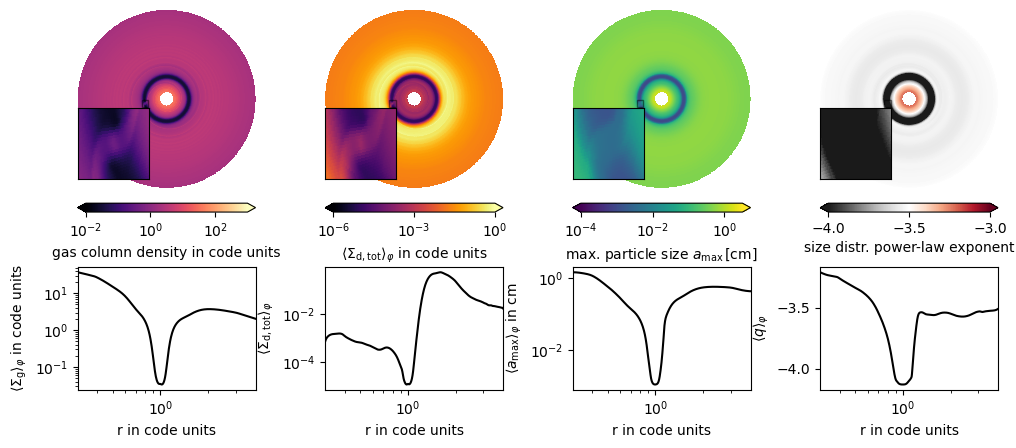

In [45]:
fig  = plt.figure(1, figsize=(10,5))
gs   = gridspec.GridSpec(2,4, height_ratios=[1,0.4])

ax0  = plt.subplot(gs[0,0])
ax0i = plt.subplot(gs[1,0])

ax1  = plt.subplot(gs[0,1])
ax1i = plt.subplot(gs[1,1])

ax2  = plt.subplot(gs[0,2])
ax2i = plt.subplot(gs[1,2])

ax3  = plt.subplot(gs[0,3])
ax3i = plt.subplot(gs[1,3])

#
# Plot gas density
#
plot0 = ax0.pcolormesh(x,y,sigg,norm=LogNorm(vmin=1e-2,vmax=1e3), cmap='magma', rasterized=True)
ax0.axis('off')
ax0.set_xlim(-20,20)
ax0.axis('scaled')
plt.colorbar(plot0, ax=ax0, orientation='horizontal', label=r'gas column density in code units', extend='both', pad=0.05)

axins0 = ax0.inset_axes(
    [0.0, 0.05, 0.4, 0.4],
    xlim=(x1, x2), ylim=(y1, y2), xticklabels=[], yticklabels=[])
axins0.pcolormesh(x,y,sigg,norm=LogNorm(vmin=1e-2,vmax=1e3), cmap='magma', rasterized=True)
axins0.set_xticks([])
axins0.set_yticks([])
ax0.indicate_inset_zoom(axins0, edgecolor="black")

ax0i.loglog(r, sigg.mean(0), color='k')
ax0i.set_xlabel("r in code units")
ax0i.set_ylabel(r"$\langle \Sigma_\mathrm{g} \rangle_\varphi$ in code units")
ax0i.set_xlim(r.min(), r.max())

#
# Plot dust-to-gas ratio
#
plot1 = ax1.pcolormesh(x,y,(sigd_0 + sigd_1), norm=LogNorm(vmin=1e-6, vmax=1), cmap='inferno', rasterized=True)
ax1.set_xlim(-20,20)
ax1.axis('scaled')
ax1.axis('off')
plt.colorbar(plot1, ax=ax1, orientation='horizontal', label=r"$\langle \Sigma_\mathrm{d,tot} \rangle_\varphi$ in code units", extend='both', pad=0.05)

axins1 = ax1.inset_axes(
    [0.0, 0.05, 0.4, 0.4],
    xlim=(x1, x2), ylim=(y1, y2), xticklabels=[], yticklabels=[])
axins1.pcolormesh(x,y,(sigd_0 + sigd_1), norm=LogNorm(vmin=1e-6, vmax=1), cmap='inferno', rasterized=True)
axins1.set_xticks([])
axins1.set_yticks([])
ax1.indicate_inset_zoom(axins1, edgecolor="black")

ax1i.loglog(r, (sigd_0 + sigd_1).mean(0), color='k')
ax1i.set_xlabel("r in code units")
ax1i.set_ylabel(r"$\langle \Sigma_\mathrm{d,tot} \rangle_\varphi$")
ax1i.set_xlim(r.min(), r.max())

#
# Plot particle sizes
#
plot2 = ax2.pcolormesh(x,y,amax, norm=LogNorm(vmin=1e-4, vmax=np.sqrt(1*10)), cmap='viridis', rasterized=True)
ax2.set_xlim(-20,20)
ax2.axis('scaled')
ax2.axis('off')
plt.colorbar(plot2, ax=ax2, orientation='horizontal', label=r'max. particle size $a_\mathrm{\max} \, \mathrm{[cm]}$',extend='both', pad=0.05)

axins2 = ax2.inset_axes(
    [0.0, 0.05, 0.4, 0.4],
    xlim=(x1, x2), ylim=(y1, y2), xticklabels=[], yticklabels=[])
axins2.pcolormesh(x,y,amax, norm=LogNorm(vmin=1e-4, vmax=np.sqrt(1*10)), cmap='viridis', rasterized=True)
axins2.set_xticks([])
axins2.set_yticks([])
ax2.indicate_inset_zoom(axins2, edgecolor="black")

ax2i.loglog(r, amax.mean(0), color='k')
ax2i.set_xlabel("r in code units")
ax2i.set_ylabel(r"$\langle a_\mathrm{max} \rangle_\varphi$ in cm")
ax2i.set_xlim(r.min(), r.max())

#
# Plot power-law index
#
plot3 = ax3.pcolormesh(x,y,q, vmin=-4., vmax=-3.0, cmap='RdGy_r', rasterized=True)
ax3.set_xlim(-20,20)
ax3.axis('scaled')
ax3.axis('off')
plt.colorbar(plot3, ax=ax3, orientation='horizontal', label=r'size distr. power-law exponent', extend='both', pad=0.05)

axins3 = ax3.inset_axes(
    [0.0, 0.05, 0.4, 0.4],
    xlim=(x1, x2), ylim=(y1, y2), xticklabels=[], yticklabels=[])
axins3.pcolormesh(x,y,q, vmin=-4., vmax=-3.0, cmap='RdGy_r', rasterized=True)
axins3.set_xticks([])
axins3.set_yticks([])
ax3.indicate_inset_zoom(axins3, edgecolor="black")

ax3i.semilogx(r, q.mean(0), color='k')
ax3i.set_xlabel("r in code units")
ax3i.set_ylabel(r"$\langle q \rangle_\varphi$")
ax3i.set_xlim(r.min(), r.max())

gs.tight_layout(fig, pad=0.1, h_pad=-0.5)

Now we can see a ***planet-induced gap*** has formed and the particles have grown to centimeter sizes. While the regions outside of the planet's orbit have again adopted an MRN distribution, we can see that ***the size distribution has changed in the gap***. It is now shallower. A sign that we are not in coagulation-fragmentation equilibrium anymore. Instead, the dust distribition is now mostly determined by transport effects within the gap.  
Large grains cannot enter the gap due to the pressure maximum. Only smaller grains diffuse into the gap. 

## Reconstructing the full size distribution

A more familiar view at this is a color map of the actual size distribution as a function of distance to the star and particle size - the typical "DustPy plot", as we have seen in Sebastian's tutorial. 
Let's reconstruct the full size distribution from the 2D ```TriPoD``` data and plot this.

In [46]:
# First, we have to define a particle size grid on which to reconstruct the distribution
# Since our particles have grown to mm in size, we define a log-spaced grid from 1e-5 cm to 5cm.
# The number of bins is arbitrary. I've just chosen 120. 

ai = np.geomspace(amin, 5, 120)
a  = 0.5*(ai[1:] + ai[:-1])

# Let's calculate the azimuthally averaged distribution:
amax_m = amax.mean(0)
sigd   = (sigd_0+sigd_1)
sigd_m = sigd.mean(0)
sigg_m = sigg.mean(0)
q_m    = q.mean(0)

We can loop through the array and assign the respective integrated dust density:

In [50]:
%%time
sig_recon = np.zeros((len(r), len(a))) # allocate array 
for i in range(len(r)): # loop over radial grid 
    for j in range(len(a)): # loop over size grid
        if(ai[j+1]<amax_m[i]):
            sig_recon[i,j] = ai[j+1]**(q_m[i]+4.) - ai[j]**(q_m[i]+4.)
        elif(ai[j]<amax_m[i] and ai[j+1]>amax_m[i]):
            sig_recon[i,j] = amax_m[i]**(q_m[i]+4.) - ai[j]**(q_m[i]+4.)
        else:
            sig_recon[i,j] = 1e-100
sig_recon *= ((sigd_m)[:,None]/(amax_m[:,None]**(q_m[:,None]+4) - amin**(q_m[:,None]+4))) # Normalize
sig_recon = np.maximum(1e-100, sig_recon) # Set floor for log plotting

CPU times: user 63.9 ms, sys: 11 µs, total: 63.9 ms
Wall time: 65.2 ms


Or, better, we can use numpy functions instead. 
These nested ```np.where``` functions check where in the array the given conditional is fulfilled and then assign the values given as the other two arguments.
Basically, if the arrays are 2D:

```
def where(cond,a,b):
    res = np.zeros_like(a)
    for i in range(a.shape[0]):
        for j in range(a.shape[1]):
            if(cond):
                res[i,j] = a[i,j]
            else:
                res[i,j] = b[i,j]
    return res
```

In [51]:
%%time
# Since we are working with numpy arrays we can also do it with stacked np.where. 
# The structure is similar to our for loops from before. 
sig_recon_ = np.where(ai[None,1:]<amax_m[...,None], 
                      ai[None,1:]**(q_m[...,None]+4.) - ai[None,:-1]**(q_m[...,None]+4.), 
                      np.where(np.logical_and(ai[None,:-1]<amax_m[...,None], ai[None,1:]>amax_m[...,None]), 
                               amax_m[...,None]**(q_m[...,None]+4.) - ai[None,:-1]**(q_m[...,None]+4.), 
                               1e-100
                               )
                      )
sig_recon_ *= ((sigd_m)[:,None]/(amax_m[:,None]**(q_m[:,None]+4) - amin**(q_m[:,None]+4)))
sig_recon_ = np.maximum(1e-100, sig_recon_)

CPU times: user 8.87 ms, sys: 4 µs, total: 8.87 ms
Wall time: 10.1 ms


In [49]:
sig_recon[ai[None,1:]<amax_m[...,None]].shape

(54568,)

Results should of course be the same ***(we need double precision for this to be true)***.

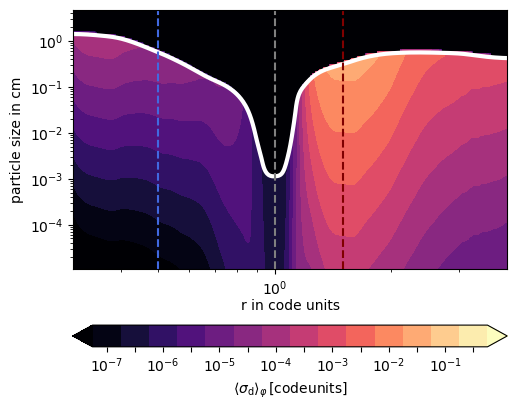

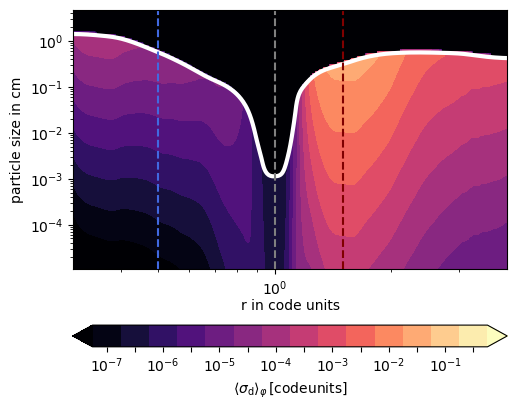

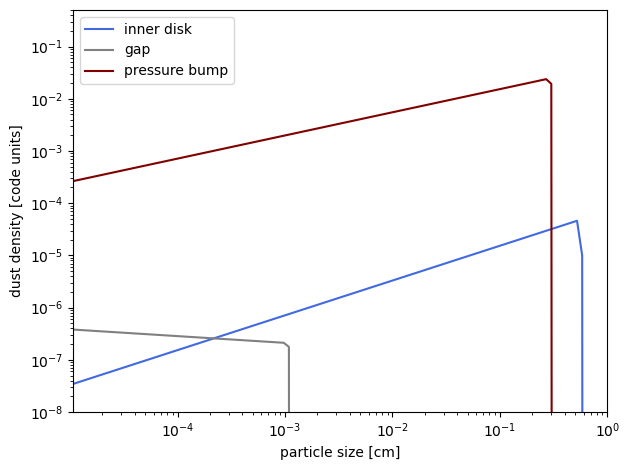

In [52]:
ticks = np.geomspace(1e-7, np.sqrt(0.1*1),14)
diff = np.diff(np.log10(ticks))[0]/2
ticks_b = np.logspace(np.log10(ticks[0])-diff, np.log10(ticks[-1])+diff, len(ticks)+1)

plt.figure(figsize=(5, 4))
plt.contourf(r, a, sig_recon.T, norm=LogNorm(), levels=ticks_b, cmap='magma', extend='both')
plt.loglog(r, amax_m, lw=3, color='w')
# plt.loglog(r, np.sqrt(amin*amax_m), lw=1, color='w')
cbar = plt.colorbar(orientation='horizontal', label=r'$\langle\sigma_\mathrm{d}\rangle_\varphi\, \mathrm{[code units]}$')
cbar.set_ticks(ticks)
plt.xlabel('r in code units', labelpad=0.5)
plt.ylabel('particle size in cm')
plt.axvline(0.5, linestyle='--', color='royalblue')
plt.axvline(1., linestyle='--', color='grey')
plt.axvline(1.5, linestyle='--', color='maroon')
plt.tight_layout(pad=0.1)

plt.figure(figsize=(5, 4))
plt.contourf(r, a, sig_recon_.T, norm=LogNorm(), levels=ticks_b, cmap='magma', extend='both')
plt.loglog(r, amax_m, lw=3, color='w')
# plt.loglog(r, np.sqrt(amin*amax_m), lw=1, color='w')
cbar = plt.colorbar(orientation='horizontal', label=r'$\langle\sigma_\mathrm{d}\rangle_\varphi\, \mathrm{[code units]}$')
cbar.set_ticks(ticks)
plt.xlabel('r in code units', labelpad=0.5)
plt.ylabel('particle size in cm')
plt.axvline(0.5, linestyle='--', color='royalblue')
plt.axvline(1., linestyle='--', color='grey')
plt.axvline(1.5, linestyle='--', color='maroon')
plt.tight_layout(pad=0.1)

i_inner  = np.argmin(np.abs(r-0.5))
i_planet = np.argmin(np.abs(r-1.))
i_trap   = np.argmin(np.abs(r-1.5))
plt.figure()
plt.loglog(a, sig_recon[i_inner], color='royalblue', label='inner disk')
plt.loglog(a, sig_recon[i_planet], color='grey', label='gap')
plt.loglog(a, sig_recon[i_trap], color='maroon', label='pressure bump')
plt.ylim(1e-8, 0.5)
plt.xlim(a.min(), 1)
plt.legend()
plt.xlabel('particle size [cm]')
plt.ylabel('dust density [code units]')
plt.tight_layout()

# plt.figure(figsize=(5, 4))
# plt.pcolormesh(r, a, (sig_recon/sig_recon_ - 1.).T*100., cmap='coolwarm', vmin=-1e-5, vmax=1e-5)
# # plt.loglog(r, np.sqrt(amin*amax_m), lw=1, color='w')
# cbar = plt.colorbar(orientation='horizontal', label=r'deviation in per cent')
# plt.xlabel('r in code units', labelpad=0.5)
# plt.ylabel('particle size in cm')
# plt.tight_layout(pad=0.1)
# plt.loglog()

## 2D dust size distributions
Instead of calculating the azimuthally averaged size distribution, we can also calculate the size distribution in every grid cell (i.e., at every $r$ and $\varphi$).
Doing this, it becomes advantageous to use the ```np.where``` function, which is almost 10 times faster:

In [53]:
# %%time
# # This should take some 45 seconds ... 
# sig_recon2d = np.zeros((len(phi), len(r), len(a))) # allocate array 
# for i in range(len(r)): # loop over radial grid 
#     for j in range(len(phi)):
#         for k in range(len(a)): # loop over size grid
#             if(ai[k+1]<amax[j,i]):
#                 sig_recon2d[j,i,k] = ai[k+1]**(q[j,i]+4.) - ai[k]**(q[j,i]+4.)
#             elif(ai[k]<amax[j,i] and ai[k+1]>amax[j,i]):
#                 sig_recon2d[j,i,k] = amax[j,i]**(q[j,i]+4.) - ai[k]**(q[j,i]+4.)
#             else:
#                 sig_recon2d[j,i,k] = 1e-100
#         sig_recon2d[j,i] *= (sigd[j,i]/(amax[j,i]**(q[j,i]+4.) - amin**(q[j,i]+4.))) 
#         sig_recon2d[j,i] = np.maximum(1e-100, sig_recon2d[j,i]) # set lower limit

In [54]:
%%time
sig_recon2d_ = np.where(ai[None,1:]<amax[...,None], 
                        ai[None,1:]**(q[...,None]+4.) - ai[None,:-1]**(q[...,None]+4.), 
                        np.where(np.logical_and(ai[None,:-1]<amax[...,None], ai[None,1:]>amax[...,None]), 
                                 amax[...,None]**(q[...,None]+4.) - ai[None,:-1]**(q[...,None]+4.), 
                                 1e-100
                                )
                       )
sig_recon2d_ *= ((sigd)[...,None]/(amax[...,None]**(q[...,None]+4) - amin**(q[...,None]+4)))
sig_recon2d_ = np.maximum(1e-100, sig_recon2d_)

CPU times: user 4.13 s, sys: 267 ms, total: 4.4 s
Wall time: 4.41 s


Plotting a slice of the data instead of the azimuthal average we can now see the effects of the spiral density waves, that introduce wiggles in the dust density:

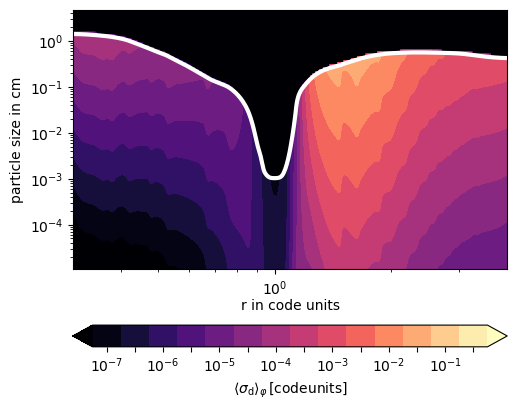

In [55]:
plt.figure(figsize=(5, 4))
plt.contourf(r, a, sig_recon2d_[0].T, norm=LogNorm(), levels=ticks_b, cmap='magma', extend='both')
plt.loglog(r, amax[0], lw=3, color='w')
cbar = plt.colorbar(orientation='horizontal', label=r'$\langle\sigma_\mathrm{d}\rangle_\varphi\, \mathrm{[code units]}$')
cbar.set_ticks(ticks)
plt.xlabel('r in code units', labelpad=0.5)
plt.ylabel('particle size in cm')
plt.tight_layout(pad=0.1)

# plt.figure(figsize=(5, 4))
# plt.contourf(r, a, sig_recon2d[0].T, norm=LogNorm(), levels=ticks_b, cmap='magma', extend='both')
# plt.loglog(r, amax[0], lw=3, color='w')
# cbar = plt.colorbar(orientation='horizontal', label=r'$\langle\sigma_\mathrm{d}\rangle_\varphi\, \mathrm{[g\, cm^{-2}]}$')
# cbar.set_ticks(ticks)
# plt.xlabel('r in code units', labelpad=0.5)
# plt.ylabel('particle size in cm')
# plt.tight_layout(pad=0.1)

# plt.figure(figsize=(5, 4))
# plt.pcolormesh(r, a, (sig_recon2d[0]/sig_recon2d_[0] - 1.).T*100., cmap='coolwarm', vmin=-1e-5, vmax=1e-5)
# # plt.loglog(r, np.sqrt(amin*amax_m), lw=1, color='w')
# cbar = plt.colorbar(orientation='horizontal', label=r'deviation in per cent')
# plt.xlabel('r in code units', labelpad=0.5)
# plt.ylabel('particle size in cm')
# plt.tight_layout(pad=0.1)
# plt.loglog()

We can now also have a look at the spatial distribution of dust of different sizes. While small grains are present within the gap, large grains show a very wide and empty gap:

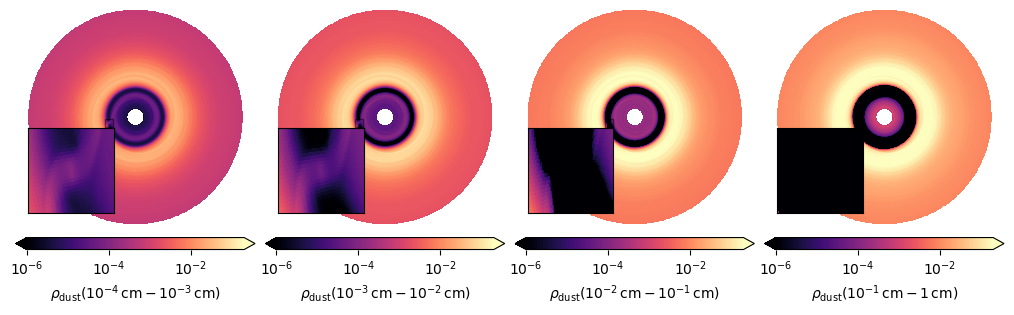

In [56]:
fig  = plt.figure(1, figsize=(10,3))
gs   = gridspec.GridSpec(1,4)

ax0  = plt.subplot(gs[0,0])
ax1  = plt.subplot(gs[0,1])
ax2  = plt.subplot(gs[0,2])
ax3  = plt.subplot(gs[0,3])

plot0 = ax0.pcolormesh(x,y,np.where(np.logical_and(a[None,None,:]>1e-4, a[None,None,:]<1e-3),sig_recon2d_,0.).sum(-1), norm=LogNorm(vmin=1e-6, vmax=0.2), cmap='magma', rasterized=True)
ax0.axis('off')
ax0.set_xlim(-20,20)
ax0.axis('scaled')
plt.colorbar(plot0, ax=ax0, orientation='horizontal', label=r'$\rho_\mathrm{dust}(10^{-4}\,\mathrm{cm}-10^{-3}\,\mathrm{cm})$', extend='both', pad=0.05)
axins0 = ax0.inset_axes(
    [0.0, 0.05, 0.4, 0.4],
    xlim=(x1, x2), ylim=(y1, y2), xticklabels=[], yticklabels=[])
axins0.pcolormesh(x,y,np.where(np.logical_and(a[None,None,:]>1e-4, a[None,None,:]<1e-3),sig_recon2d_,0.).sum(-1), norm=LogNorm(vmin=1e-6, vmax=0.2), cmap='magma', rasterized=True)
axins0.set_xticks([])
axins0.set_yticks([])
ax0.indicate_inset_zoom(axins0, edgecolor="black")

plot1 = ax1.pcolormesh(x,y,np.where(np.logical_and(a[None,None,:]>1e-3, a[None,None,:]<1e-2),sig_recon2d_,0.).sum(-1), norm=LogNorm(vmin=1e-6, vmax=0.2), cmap='magma', rasterized=True)
ax1.set_xlim(-20,20)
ax1.axis('scaled')
ax1.axis('off')
plt.colorbar(plot1, ax=ax1, orientation='horizontal', label=r'$\rho_\mathrm{dust}(10^{-3}\,\mathrm{cm}-10^{-2}\,\mathrm{cm})$', extend='both', pad=0.05)
axins1 = ax1.inset_axes(
    [0.0, 0.05, 0.4, 0.4],
    xlim=(x1, x2), ylim=(y1, y2), xticklabels=[], yticklabels=[])
axins1.pcolormesh(x,y,np.where(np.logical_and(a[None,None,:]>1e-3, a[None,None,:]<1e-2),sig_recon2d_,0.).sum(-1), norm=LogNorm(vmin=1e-6, vmax=0.2), cmap='magma', rasterized=True)
axins1.set_xticks([])
axins1.set_yticks([])
ax1.indicate_inset_zoom(axins1, edgecolor="black")

plot2 = ax2.pcolormesh(x,y,np.where(np.logical_and(a[None,None,:]>1e-2, a[None,None,:]<1e-1),sig_recon2d_,0.).sum(-1), norm=LogNorm(vmin=1e-6, vmax=0.2), cmap='magma', rasterized=True)
ax2.set_xlim(-20,20)
ax2.axis('scaled')
ax2.axis('off')
plt.colorbar(plot2, ax=ax2, orientation='horizontal', label=r'$\rho_\mathrm{dust}(10^{-2}\,\mathrm{cm}-10^{-1}\,\mathrm{cm})$',extend='both', pad=0.05)
axins2 = ax2.inset_axes(
    [0.0, 0.05, 0.4, 0.4],
    xlim=(x1, x2), ylim=(y1, y2), xticklabels=[], yticklabels=[])
axins2.pcolormesh(x,y,np.where(np.logical_and(a[None,None,:]>1e-2, a[None,None,:]<1e-1),sig_recon2d_,0.).sum(-1), norm=LogNorm(vmin=1e-6, vmax=0.2), cmap='magma', rasterized=True)
axins2.set_xticks([])
axins2.set_yticks([])
ax2.indicate_inset_zoom(axins2, edgecolor="black")

plot3 = ax3.pcolormesh(x,y,np.where(np.logical_and(a[None,None,:]>1e-1, a[None,None,:]<1),sig_recon2d_,0.).sum(-1), norm=LogNorm(vmin=1e-6, vmax=0.2), cmap='magma', rasterized=True)
ax3.set_xlim(-20,20)
ax3.axis('scaled')
ax3.axis('off')
plt.colorbar(plot3, ax=ax3, orientation='horizontal', label=r'$\rho_\mathrm{dust}(10^{-1}\,\mathrm{cm}-1\,\mathrm{cm})$', extend='both', pad=0.05)
axins3 = ax3.inset_axes(
    [0.0, 0.05, 0.4, 0.4],
    xlim=(x1, x2), ylim=(y1, y2), xticklabels=[], yticklabels=[])
axins3.pcolormesh(x,y,np.where(np.logical_and(a[None,None,:]>1e-1, a[None,None,:]<1),sig_recon2d_,0.).sum(-1), norm=LogNorm(vmin=1e-6, vmax=0.2), cmap='magma', rasterized=True)
axins3.set_xticks([])
axins3.set_yticks([])
ax3.indicate_inset_zoom(axins3, edgecolor="black")

gs.tight_layout(fig, pad=0.1, h_pad=-0.5)